Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1.CODE SCRATCH

In [1]:
import numpy as np

def distance_euclidienne(A, B):
    # """
    # Calcule la distance euclidienne entre deux points 
    # A(x1,y1) et B(x2,y2)= √((x2 - x1)² + (y2 - y1)²)
    # """
    # initialisation de la somme des carrés à 0
    s = 0 
    # on parcourt chaque dimension (coordonnée x, y) des points
    for i in range(len(A)): 
        # on calcule la différence, on la met au carré et on l'ajoute à la somme
        s = s + (B[i] - A[i])**2 
    # on retourne la racine carrée
    return s**0.5 

def obtenir_voisins(Data, x, k):
    # """
    # Calcule la distance entre le point 'x' et tous les points de 'Data',
    # puis retourne les 'k' points les plus proches.
    # """
    # initialisation d'une liste vide
    distances = [] 
    
    # on parcourt chaque point dans notre Dataset
    for d in Data: 
        # les coordonnées sont tout sauf le dernier élément (car ce sont les classes, donc le data est [X, Y, C])
        point = d[:-1] 
        # le dernier élément est la classe C du point
        classe = d[-1] 
        # on calcule la distance
        dist = distance_euclidienne(point, x) 
        # on stocke le couple (distance, classe)
        distances.append((dist, classe)) 
    
    # On trie la liste "distances" en fonction de la première valeur de chaque élément
    # lambda element: element[0] pour prendre la distance comme clé de tri, ce n'est pas le label qui est la classe
    distances.sort(key=lambda element: element[0]) 
    
    # on garde uniquement les 'k' premiers (les plus proches)
    k_plus_proches = distances[:k] 
    return k_plus_proches

def classe_majoritaire(KNN, nbr_classes):
    # """
    # Compte les occurrences de chaque classe parmi les voisins (vote).
    # """
    # initialisation du tableau de comptage des classes à zéro (combien d'occurrences de chaque classe dans ce voisinage)
    # multiplié par le nombre de classes, on obtient une liste de n zéros [0, 0, ...] première case pour classe 0, deuxième pour classe 1...
    LC = [0] * nbr_classes 
    
    # on parcourt nos k voisins
    for v in KNN: 
        # v = [distance, classe]
        # donc v[1] pour récupérer la classe C du voisin 
        # on utilise int() pour éviter l'erreur -l'indice ne doit pas être de type numpy.float64
        # on incrémente le compteur de cette classe spécifique
        LC[int(v[1])] += 1
        
    # on cherche le maximum
    imax = LC.index(max(LC))
    return imax

def KNN_scratch(Data, x, k, nbr_classes):
    # on récupère les voisins
    voisins = obtenir_voisins(Data, x, k)
    # on retourne la classe gagnante
    return classe_majoritaire(voisins, nbr_classes)

## a. DATASET

In [2]:
# On fixe la graine pour obtenir les mêmes résultats à chaque exécution
np.random.seed(42)

# Dictionnaire : classe, couleur, intervalle, dispersion et nombre de points
classes_info = {
    0: {"color": "red",   "loc": [20, 50], "scale": 8, "size": 80},
    1: {"color": "blue",  "loc": [60, 70], "scale": 8, "size": 30},
    2: {"color": "green", "loc": [60, 25], "scale": 8, "size": 60},
}

# Listes vides pour stocker tous les points et toutes les classes
points_list = []
classes_list = []

# Boucle sur chaque classe dans le dictionnaire
for item in classes_info.items():
    # c : numéro de classe (0, 1, 2...)
    c = item[0]
    # info : contient les paramètres de génération (loc, scale, size, color)
    info = item[1]

    # """
    # Génération des points (x, y) avec une distribution normale (nuage de points)
    # loc : centre du nuage [x, y]
    # scale : dispersion (écart-type), donc plus grand = points plus dispersés
    # size : nombre de points, 2 colonnes (x et y)
    # """
    XY = np.random.normal(loc=info["loc"], scale=info["scale"], size=(info["size"], 2))
    
    # Création du vecteur des classes (tous les points ont la même classe c)
    C = np.full((info["size"], 1), c)

    # On ajoute les points et les classes dans les listes
    points_list.append(XY)
    classes_list.append(C)

# On regroupe tous les points dans une seule matrice
# points_list est une liste de [[x0,y0], [x1,y1]...]
# np.vstack = transforme la liste en matrice verticale
# Résultat : une seule matrice (total_points, 2 colonnes)
points = np.vstack(points_list)

# On regroupe toutes les classes dans un seul vecteur vertical
classes = np.vstack(classes_list)

# Format final pour KNN : [[x, y], classe]
# np.hstack = transforme la liste en matrice horizontale
Data_scratch = np.hstack((points, classes))

# Point inconnu à classifier
point_a_classifier = [45, 50]

## b. Exécution du code scratch

In [3]:
# paramètre K (nombre de voisins)
k_voisins = 5

# nombre de classes possibles
nb_classes_total = len(classes_info)

# exécution de notre algorithme manuel
prediction_scratch = KNN_scratch(Data_scratch, point_a_classifier, k_voisins, nb_classes_total)

## c. Code sklearn

In [4]:
# import de la classe KNeighborsClassifier depuis la bibliothèque sklearn
from sklearn.neighbors import KNeighborsClassifier

# On crée un objet modèle en spécifiant le nombre de voisins (n_neighbors = k)
modele_sklearn_knn = KNeighborsClassifier(n_neighbors=5)

# On entraîne le modèle sur nos données (l'apprentissage en KNN consiste juste à mémoriser les points)
# .ravel() est utilisé pour transformer classes de (n, 1) à (n,)
modele_sklearn_knn.fit(points, classes.ravel())

# On demande au modèle de prédire la classe de notre point inconnu
# on ajoute [0] à la fin pour extraire la valeur du résultat du tableau renvoyé hors de la liste qui contient un seul élément
prediction_sklearn = modele_sklearn_knn.predict([point_a_classifier])[0]

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des prédictions :
Scratch : Classe 0 | Sklearn : Classe 0


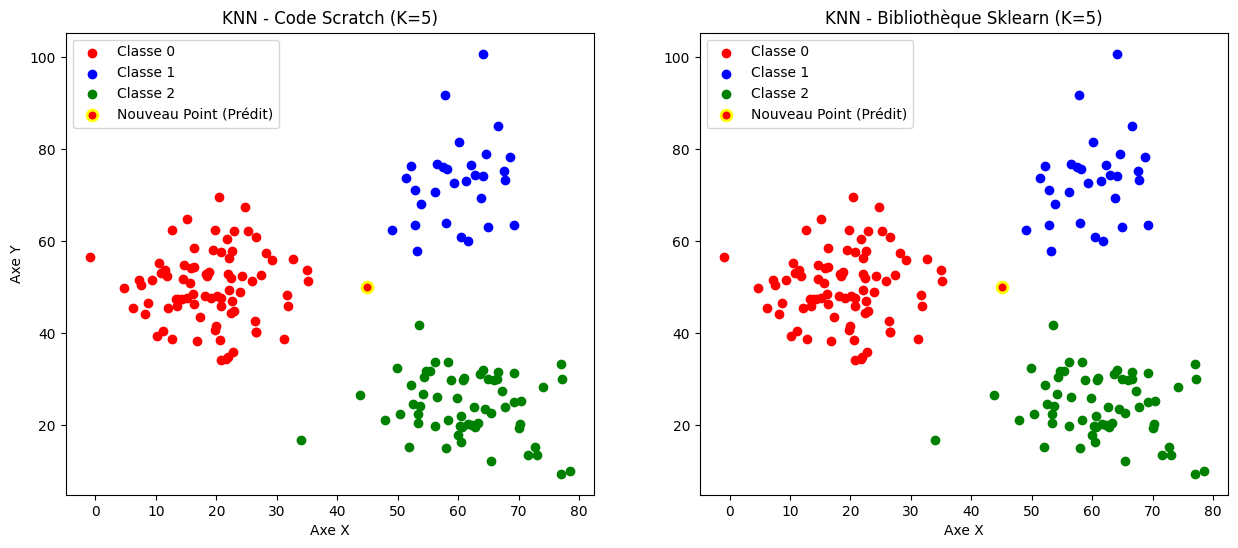

In [5]:
# d. Comparaison et graphiques (scratch/sklearn)

print("Comparaison des prédictions :")
print(f"Scratch : Classe {prediction_scratch} | Sklearn : Classe {int(prediction_sklearn)}")

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Création de la figure pour afficher les graphiques
# figsize (largeur, hauteur)
plt.figure(figsize=(15, 6))

# Graphique Scratch
# 1 ligne, 2 colonnes, graphique numéro 1
plt.subplot(1, 2, 1)

# On trace les points de chaque classe automatiquement
for item in classes_info.items():
    c=item[0]
    info=item[1]
    # On récupère toutes les valeurs X (1ere colonne) ,Y (2eme colonne)
    # Data_scratch[:, 2] == c pour lesquelles la classe (colonne 2) est égale à c
    x = Data_scratch[Data_scratch[:, 2] == c, 0]
    y = Data_scratch[Data_scratch[:, 2] == c, 1]
    plt.scatter(x, y, color=info["color"], label=f"Classe {c}")

# Définition de la couleur du point selon la prédiction scratch
couleur_pred_scratch = classes_info[prediction_scratch]["color"]

# On trace le point à classifier (une grande étoile jaune avec un bord de la couleur prédite)
plt.scatter(point_a_classifier[0],point_a_classifier[1],color=couleur_pred_scratch,edgecolor='yellow',marker='o',s=60,linewidth=2, label='Nouveau Point (Prédit)')

# Ajout des titres et légendes
plt.title('KNN - Code Scratch (K=5)')
plt.xlabel('Axe X')
plt.ylabel('Axe Y')
plt.legend()


# Graphique Sklearn
# 1 ligne, 2 colonnes, graphique numéro 2
plt.subplot(1, 2, 2)

# On re-trace les mêmes points automatiquement
for item in classes_info.items():
    c=item[0]
    info=item[1]
    # On récupère toutes les valeurs X (1ere colone) ,Y (2eme colone)
    # Data_scratch[:, 2] == c pour lesquelles la classe (colonne 2) est égale à c
    x = Data_scratch[Data_scratch[:, 2] == c, 0]
    y = Data_scratch[Data_scratch[:, 2] == c, 1]
    plt.scatter(x, y, color=info["color"], label=f"Classe {c}")

# Définition de la couleur selon la prédiction sklearn
couleur_pred_sklearn = classes_info[int(prediction_sklearn)]["color"]

# On trace le point à classifier avec la prédiction de Sklearn
plt.scatter(point_a_classifier[0],point_a_classifier[1],color=couleur_pred_sklearn,edgecolor='yellow',marker='o',s=60,linewidth=2,label='Nouveau Point (Prédit)')

# Ajout des titres et légendes
plt.title('KNN - Bibliothèque Sklearn (K=5)')
plt.xlabel('Axe X')
plt.legend()

# Affichage des deux graphiques
plt.show()